In [1]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [2]:
import os
os.chdir('..')
os.chdir('..')
os.getcwd()

'/Users/ak/Documents/GitHub/rise-project/pair_trading'

In [5]:
import numpy as np, random, os
import pandas as pd
from models import xgboost

np.random.seed(42)
random.seed(42)
os.environ["PYTHONHASHSEED"] = "42"

stock_pairs = [('MO','BTI'), 
         ('MO','HD'), 
         ('MO','LOW'), 
         ('F','BTI'), 
         ('F', 'HD'),
         ('F', 'LOW'), 
         ('STX','BTI'), 
         ('STX', 'HD'), 
         ('STX','LOW')]

tickers = sorted(set([stock for pair in stock_pairs for stock in pair]))

stock_train_prices = pd.read_csv("stocks/stock_train_prices.csv", index_col = 0, parse_dates = True)
stock_test_prices = pd.read_csv("stocks/stock_test_prices.csv", index_col = 0, parse_dates = True)

train_prices = stock_train_prices[tickers].dropna()
test_prices = stock_test_prices[tickers].dropna()

In [6]:
pair_models, pair_betas, feature_cols = xgboost.grid_search(stock_pairs, train_prices, test_prices)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.2s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.4s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.5s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=1; total time=   0.5s
[CV] END gamma=0, learning_rate=0.01, max_depth=4, min_child_weight=5; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, max_depth=6, min_child_weight=1; total time=   0.3s
[CV] END gamma=0, learning_rate=0.01, 

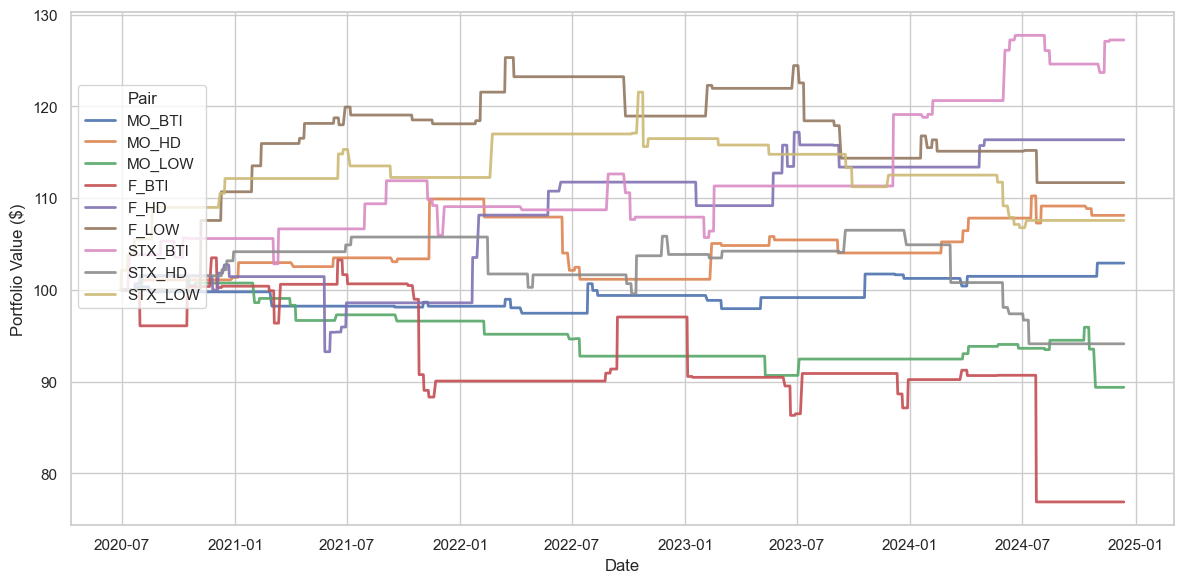

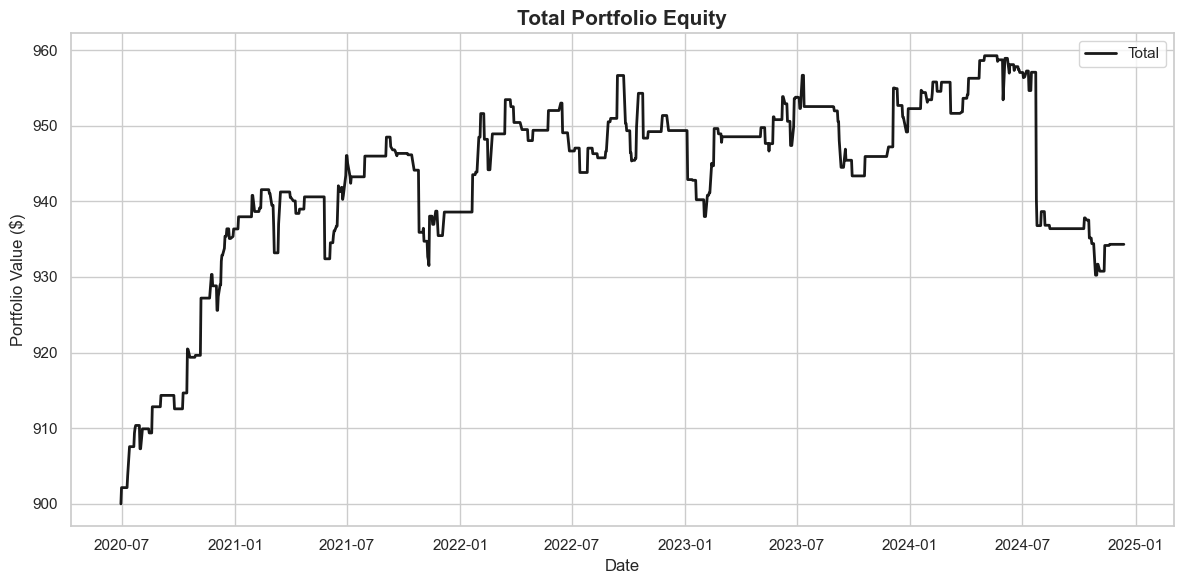

Summary
MO_BTI: Final Value = $102.92, Total Return = 2.92%, Trades = 21
MO_HD: Final Value = $108.13, Total Return = 8.13%, Trades = 26
MO_LOW: Final Value = $89.37, Total Return = -10.63%, Trades = 24
F_BTI: Final Value = $76.88, Total Return = -23.12%, Trades = 33
F_HD: Final Value = $116.37, Total Return = 16.37%, Trades = 26
F_LOW: Final Value = $111.70, Total Return = 11.70%, Trades = 30
STX_BTI: Final Value = $127.25, Total Return = 27.25%, Trades = 33
STX_HD: Final Value = $94.12, Total Return = -5.88%, Trades = 25
STX_LOW: Final Value = $107.57, Total Return = 7.57%, Trades = 26

Total Portfolio Performance
Initial Portfolio Value: $900.00
Final Portfolio Value:   $934.32
Total Return:            3.81%

Sharpe Ratios
MO_BTI: Sharpe Ratio = 0.26
MO_HD: Sharpe Ratio = 0.39
MO_LOW: Sharpe Ratio = -0.67
F_BTI: Sharpe Ratio = -0.47
F_HD: Sharpe Ratio = 0.56
F_LOW: Sharpe Ratio = 0.44
STX_BTI: Sharpe Ratio = 0.82
STX_HD: Sharpe Ratio = -0.28
STX_LOW: Sharpe Ratio = 0.36

Total Portf

Exception ignored in: <function ResourceTracker.__del__ at 0x110421a80>
Traceback (most recent call last):
  File "/opt/anaconda3/envs/rise-project/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/opt/anaconda3/envs/rise-project/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/opt/anaconda3/envs/rise-project/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessError: [Errno 10] No child processes
Exception ignored in: <function ResourceTracker.__del__ at 0x105bbda80>
Traceback (most recent call last):
  File "/opt/anaconda3/envs/rise-project/lib/python3.12/multiprocessing/resource_tracker.py", line 77, in __del__
  File "/opt/anaconda3/envs/rise-project/lib/python3.12/multiprocessing/resource_tracker.py", line 86, in _stop
  File "/opt/anaconda3/envs/rise-project/lib/python3.12/multiprocessing/resource_tracker.py", line 111, in _stop_locked
ChildProcessError: [Errno 10] No child proces

In [ ]:
xgboost.run_simulation(stock_pairs, test_prices, pair_models, feature_cols, pair_betas)